In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
demo = pd.read_csv('df_final_demo.csv')
experiment = pd.read_csv('df_final_experiment_clients.csv')
web_pt1 = pd.read_csv('df_final_web_data_pt_1.csv')
web_pt2 = pd.read_csv('df_final_web_data_pt_2.csv')

web = pd.concat([web_pt1, web_pt2], ignore_index=True)

##  DATASET INFORMATION

| Column               | Description                                             |
| -------------------- | ------------------------------------------------------- |
| **client_id**        | Unique identifier for each client                       |
| **variation**        | Indicates whether the client was part of the experiment |
| **visitor_id**       | Unique ID for each client–device combination            |
| **visit_id**         | Unique identifier for each web visit/session            |
| **process_step**     | Represents each step in the digital process             |
| **date_time**        | Timestamp of each web activity                          |
| **clnt_tenure_yr**   | Client tenure with Vanguard (in years)                  |
| **clnt_tenure_mnth** | Client tenure with Vanguard (in months)                 |
| **clnt_age**         | Age of the client                                       |
| **gendr**            | Gender of the client                                    |
| **num_accts**        | Number of accounts held by the client                   |
| **bal**              | Total balance across all client accounts                |
| **calls_6_mnth**     | Number of calls made by the client in the past 6 months |
| **logons_6_mnth**    | Number of platform logins in the past 6 months          |


In [3]:
demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [4]:
demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  object 
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 4.8+ MB


In [5]:
demo.isnull().sum()

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [32]:
demo[demo.isnull().any(axis=1)]

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
demo.dropna(inplace=True)
#Decided to drop the rows with missing values since they were only 14/15 rows and they were not affecting the overall distribution of the data. 

In [34]:
demo.isnull().sum()

client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            0
gendr               0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
dtype: int64

In [35]:
demo.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,7.059400e+04,70594.000000,70594.000000,70594.000000,70594.000000,7.059400e+04,70594.000000,70594.000000
mean,5.005026e+06,12.053007,150.659999,46.442240,2.255532,1.474467e+05,3.382469,5.566720
std,2.877289e+06,6.871850,82.090264,15.591273,0.535000,3.015106e+05,2.236595,2.353296
min,1.690000e+02,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519543e+06,6.000000,82.000000,32.500000,2.000000,3.734660e+04,1.000000,4.000000
50%,5.016974e+06,11.000000,136.000000,47.000000,2.000000,6.333459e+04,3.000000,5.000000
75%,7.483074e+06,16.000000,192.000000,59.000000,2.000000,1.375461e+05,6.000000,7.000000
max,9.999839e+06,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


In [40]:
print("Duplicate clinet_ids:", demo["client_id"].duplicated().sum())
print("/nGender values:")
print(demo["gendr"].value_counts(dropna=False))

Duplicate clinet_ids: 0
/nGender values:
gendr
U    24125
M    23724
F    22745
Name: count, dtype: int64


In [39]:
demo["gendr"].replace({"X": "U"}, inplace=True)

In [47]:
gendr_percentage=(demo["gendr"].value_counts()/len(demo["gendr"])*100).round(2)
gendr_percentage

gendr
U    34.17
M    33.61
F    32.22
Name: count, dtype: float64

In [49]:
demo['clnt_age'].describe()

count    70594.000000
mean        46.442240
std         15.591273
min         13.500000
25%         32.500000
50%         47.000000
75%         59.000000
max         96.000000
Name: clnt_age, dtype: float64

In [10]:
experiment.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [31]:
experiment.isnull().sum()

client_id        0
Variation    20109
dtype: int64

In [11]:
print("Shape:", experiment.shape)
print("Duplicate clinet_ids:", experiment["client_id"].duplicated().sum())
print("/nGroup sizes:")
print(experiment["Variation"].value_counts())

Shape: (70609, 2)
Duplicate clinet_ids: 0
/nGroup sizes:
Variation
Test       26968
Control    23532
Name: count, dtype: int64


In [13]:
demo_ids = set(demo["client_id"])
exp_ids = set(experiment["client_id"])

print(f"Clients in demo only:        {len(demo_ids - exp_ids)}")
print(f"Clients in experiment only:  {len(exp_ids - demo_ids)}")
print(f"Clients in both:             {len(demo_ids & exp_ids)}")

Clients in demo only:        0
Clients in experiment only:  0
Clients in both:             70609


In [17]:
web.head(10)
#think about clients that go back and fort between steps, and how to handle that. Maybe we can just look at the first step for each client, or the last step, or the most common step. We can also look at the time spent on each step, and see if there are any patterns there.

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
5,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:17:15
6,9988021,580560515_7732621733,781255054_21935453173_531117,step_1,2017-04-17 15:17:01
7,9988021,580560515_7732621733,781255054_21935453173_531117,start,2017-04-17 15:16:22
8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05
9,8320017,39393514_33118319366,960651974_70596002104_312201,step_3,2017-04-05 13:09:43


In [16]:
web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 755405 entries, 0 to 755404
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     755405 non-null  int64 
 1   visitor_id    755405 non-null  object
 2   visit_id      755405 non-null  object
 3   process_step  755405 non-null  object
 4   date_time     755405 non-null  object
dtypes: int64(1), object(4)
memory usage: 28.8+ MB


In [30]:
print("Duplicate client_ids:", web["client_id"].duplicated().sum())

Duplicate client_ids: 635248


In [29]:
web.groupby("client_id").size().describe()

count    120157.000000
mean          6.286816
std           3.986973
min           1.000000
25%           5.000000
50%           5.000000
75%           7.000000
max         111.000000
dtype: float64

In [24]:
web["date_time"] = pd.to_datetime(web["date_time"])
print("Date range:", web["date_time"].min(), "to", web["date_time"].max())
print("\nProcess steps:")
print(web["process_step"].value_counts()) #How many times each step in the digital journey occurs

Date range: 2017-03-15 00:03:03 to 2017-06-20 23:59:57

Process steps:
process_step
start      243945
step_1     163193
step_2     133062
step_3     112242
confirm    102963
Name: count, dtype: int64


## 🧩 Data Hierarchy

```
client (client_id)
└── visitor (visitor_id) — one per device the client uses
    └── visit (visit_id) — one per session/web visit
        └── process_step — one action within that session
```

---

## 📌 Key Notes

- A single **client** can:
  - Use **multiple devices** → multiple `visitor_id`
  - Have **multiple visits per device** → multiple `visit_id`
  - Perform **multiple steps per visit** → multiple rows per `visit_id`

---

## 🎯 Why This Matters

Understanding this hierarchy determines how you measure and analyze behavior:

- **Completion rate**
  - Should it be measured per **client**, **visitor**, or **visit**?

- **Time per step**
  - Must be calculated **within the same visit/session**

- **Error rate**
  - Example: users going **backwards within a visit**

- **Avoid incorrect counting**
  - Counting rows ≠ counting visits or clients

```
client (client_id)
└── visitor (visitor_id) — one per device the client uses
    └── visit (visit_id) — one per session/web visit
        └── process_step — one action within that session
```

In [26]:
print("Unique clients in web data: ", web["client_id"].nunique())
print("Unique visitors: ", web["visitor_id"].nunique())
print("Unique visits (sessions): ", web["visit_id"].nunique())
print("Total rows (step events): ", len(web))

Unique clients in web data:  120157
Unique visitors:  130236
Unique visits (sessions):  158095
Total rows (step events):  755405


## 🔗 How the Datasets Connect

All three datasets link through `client_id`:

```
demo (client profile)
        └── client_id → Full picture per client
experiment (Test/Ctrl)
        └── client_id → Full picture per client
web (activity logs)
        └── client_id → Web behavior per client
```

---

## 📌 Key Idea

- `client_id` is the **common key** across all datasets  
- It allows you to **merge data** and build a **complete view of each client**

---

## ⚠️ Before Merging — Important Check

Always verify whether all clients appear in all datasets:

- Are there clients in **experiment** but not in **web**?
- Are there clients in **web** but not in **experiment**?
- Do all clients exist in **demo**?

---

In [27]:
web_ids = set(web["client_id"])

print(f"Clients in demo:        {len(demo_ids):,}")
print(f"Clients in experiment:  {len(exp_ids):,}")
print(f"Clients in web:         {len(web_ids):,}")

print()

print(f"In all three:                {len(demo_ids & exp_ids & web_ids):,}")
print(f"In experiment but NOT in web:{len(exp_ids - web_ids):,}")
print(f"In web but NOT in experiment:{len(web_ids - exp_ids):,}")

Clients in demo:        70,609
Clients in experiment:  70,609
Clients in web:         120,157

In all three:                70,609
In experiment but NOT in web:0
In web but NOT in experiment:49,548


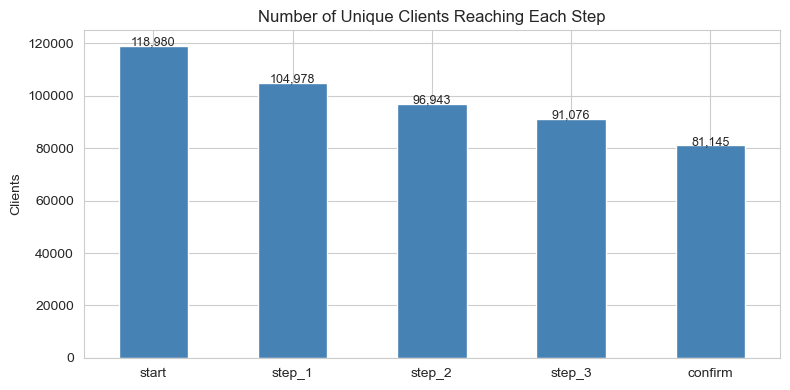

In [ ]:
step_order = ["start", "step_1", "step_2", "step_3", "confirm"]

clients_per_step = (
    web.groupby("process_step")["client_id"]
    .nunique()
    .reindex(step_order)
)

fig, ax = plt.subplots(figsize=(8, 4))

clients_per_step.plot(
    kind="bar",
    ax=ax,
    color="steelblue",
    edgecolor="white"
)

ax.set_title("Number of Unique Clients Reaching Each Step")
ax.set_ylabel("Clients")
ax.set_xlabel("")
ax.set_xticklabels(step_order, rotation=0)

for i, v in enumerate(clients_per_step.values):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

#Important Funnel, Customer start dropping throught the process.

## What's Next?

You now have a foundation. From here, your next steps are:

1. **Clean the data** — handle nulls, duplicates, type inconsistencies  
2. **Merge the datasets** — decide on the right merge strategy  
3. **Compute your KPIs** — completion rate, time per step, error rate (per group)  
4. **Compare Test vs. Control** — are there real differences?  
5. **Run hypothesis tests** — are those differences statistically significant?  

In [68]:
merged = demo.merge(experiment, on="client_id", how="inner")

merged.columns = merged.columns.str.strip().str.lower().str.replace(" ", "_")

merged.head()



,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control


In [72]:
grouped = merged.groupby("variation").agg({
    "clnt_age": ["mean", "median"],
    "num_accts": ["mean"],
    "clnt_tenure_yr": ["mean"],
    "gendr": lambda x: x.value_counts().to_dict()
})
grouped

clnt_age        num_accts clnt_tenure_yr  \
                mean median      mean           mean   
variation                                              
Control    47.498427   48.5  2.259925      12.087860   
Test       47.163922   47.5  2.249917      11.982901   

                                       gendr  
                                    <lambda>  
variation                                     
Control    {'U': 8014, 'M': 7970, 'F': 7542}  
Test       {'U': 9268, 'M': 8977, 'F': 8716}

In [74]:
counts = merged["variation"].value_counts()
print(counts)

variation
Test       26961
Control    23526
Name: count, dtype: int64


In [79]:
variance_percentage = (
    merged["variation"]
    .value_counts(normalize=True) * 100
).round(2)

variance_percentage

variation
Test       53.4
Control    46.6
Name: proportion, dtype: float64